In [32]:
"""
Linear Models Pipeline (Ridge / Lasso / ElasticNet)
Optimized using P90 Absolute Percentage Error
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import loguniform

df_train = pd.read_csv('ram.csv')
df_test = pd.read_csv('testram.csv')


def convert_memory(mem_str):
    mem_str = str(mem_str).lower()
    if 'g' in mem_str:
        return float(mem_str.replace('g', '')) * 1024
    elif 'm' in mem_str:
        return float(mem_str.replace('m', ''))
    return float(mem_str)

def preprocess(df):
    df = df.copy()

    df['device_write_numeric'] = df['device_write'].str.replace('mb', '').astype(float)
    df['memory_numeric'] = df['memory'].apply(convert_memory)

    df = df[df['Throughput'] != 0]

    # Feature engineering
    df['load_per_cpu'] = df['ArrivalRate'] / (df['cpus'] + 1e-6)
    df['cpu_capacity'] = df['cpus'] * (1 - df['cpuLoad'])
    df['utilization'] = df['ArrivalRate'] / (df['cpu_capacity'] + 1e-6)

    return df

train = preprocess(df_train)
test = preprocess(df_test)

X_cols = [
    'ArrivalRate', 'cpus', 'size', 'cpuLoad',
    'device_write_numeric', 'memory_numeric',
    'load_per_cpu', 'cpu_capacity', 'utilization'
]

X_train = train[X_cols].values
X_test = test[X_cols].values

# Log-transform targets
y_tp_train = np.log1p(train['Throughput'].values)
y_tp_test = np.log1p(test['Throughput'].values)

y_rt_train = np.log1p(train['ResponseTime'].values)
y_rt_test = np.log1p(test['ResponseTime'].values)


def p90_ape(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100
    return np.percentile(pct_err, 90)

from sklearn.metrics import make_scorer
p90_scorer = make_scorer(p90_ape, greater_is_better=False)


def tune_model(model_name, X, y):
    print(f"\nTuning {model_name} (P90 APE)...")

    if model_name == "ridge":
        model = Ridge()
        param_dist = {
            'model__alpha': loguniform(1e-4, 100)
        }

    elif model_name == "lasso":
        model = Lasso(max_iter=10000)
        param_dist = {
            'model__alpha': loguniform(1e-4, 10)
        }

    elif model_name == "elastic":
        model = ElasticNet(max_iter=10000)
        param_dist = {
            'model__alpha': loguniform(1e-4, 10),
            'model__l1_ratio': np.linspace(0.1, 0.9, 9)
        }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=20,
        scoring=p90_scorer,
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best CV P90 APE:", -search.best_score_)

    return search.best_estimator_



model_tp = tune_model("ridge", X_train, y_tp_train)
model_rt = tune_model("elastic", X_train, y_rt_train)


def evaluate(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100

    p90 = np.percentile(pct_err, 90)
    mape = np.mean(pct_err)
    smape = np.mean(2 * np.abs(y_pred - y_true) /
                    (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)

    acc_10 = (pct_err <= 10).mean() * 100
    acc_20 = (pct_err <= 20).mean() * 100
    acc_50 = (pct_err <= 50).mean() * 100

    print(f"\n{name} RESULTS")
    print("-" * 40)
    print(f"P90 APE:        {p90:.2f}%  PRIMARY METRIC")
    print(f"MAPE:           {mape:.2f}%")
    print(f"SMAPE:          {smape:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"R²:             {r2:.4f}")
    print(f"Acc ≤10%:       {acc_10:.2f}%")
    print(f"Acc ≤20%:       {acc_20:.2f}%")
    print(f"Acc ≤50%:       {acc_50:.2f}%")



evaluate(y_tp_test, model_tp.predict(X_test), "THROUGHPUT")
evaluate(y_rt_test, model_rt.predict(X_test), "RESPONSE TIME")


Tuning ridge (P90 APE)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__alpha': np.float64(0.00013289448722869195)}
Best CV P90 APE: 123.4523376780369

Tuning elastic (P90 APE)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__alpha': np.float64(0.00010090061869151566), 'model__l1_ratio': np.float64(0.5)}
Best CV P90 APE: 6189.255911447406

THROUGHPUT RESULTS
----------------------------------------
P90 APE:        35.41%  PRIMARY METRIC
MAPE:           13.62%
SMAPE:          0.1393
RMSE:           2.5193
MAE:            1.7525
R²:             0.4286
Acc ≤10%:       53.33%
Acc ≤20%:       83.33%
Acc ≤50%:       100.00%

RESPONSE TIME RESULTS
----------------------------------------
P90 APE:        1798.99%  PRIMARY METRIC
MAPE:           528.28%
SMAPE:          1.0618
RMSE:           39807.5784
MAE:            23216.7490
R²:             -1.0871
Acc ≤10%:       10.00%
Acc ≤20%:       20.00%
Acc ≤50%:       30.00%


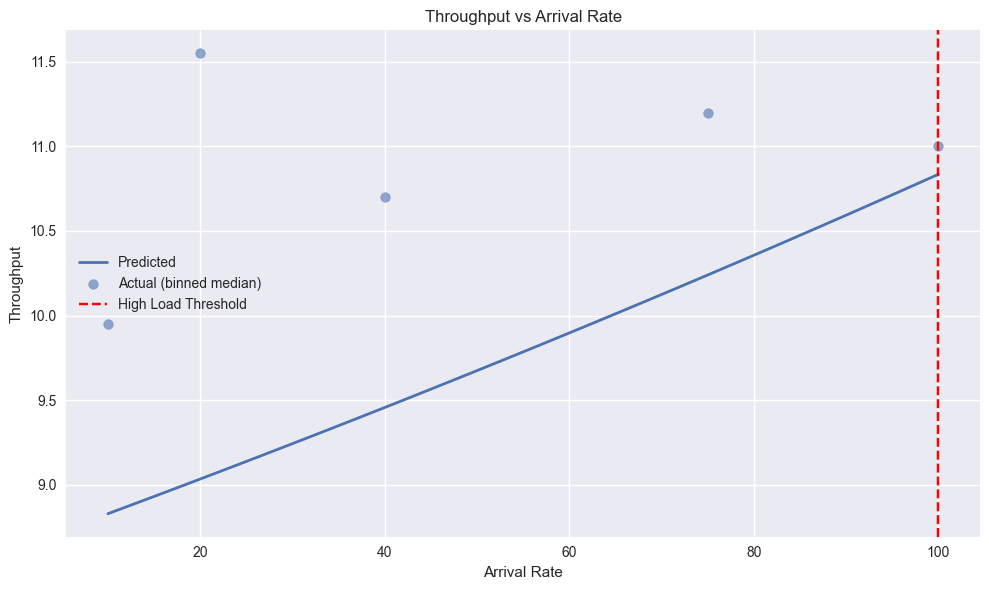

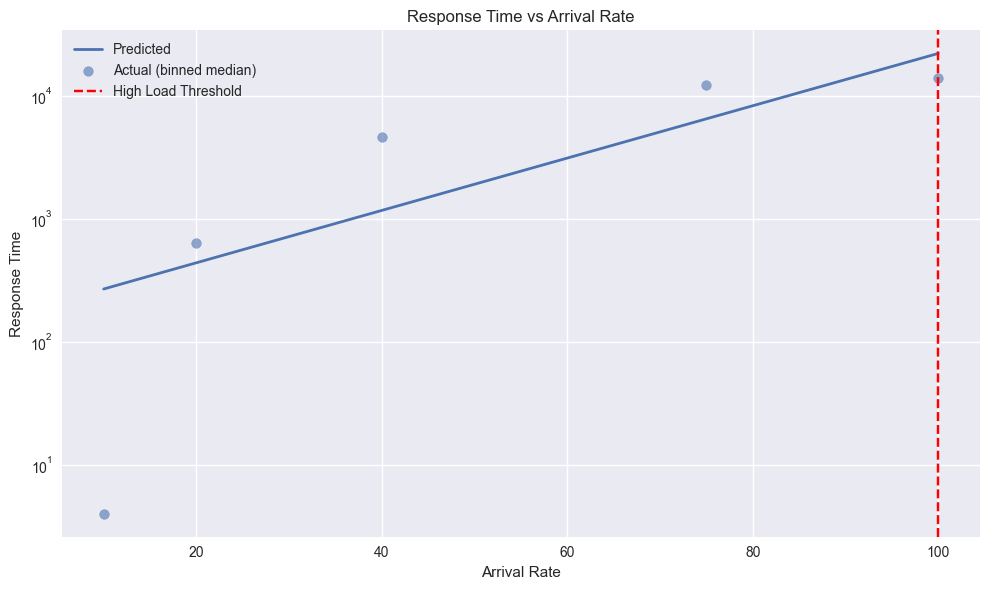

In [33]:
"""
Arrival Rate Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


def create_arrival_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    arrival_range = np.linspace(
        df['ArrivalRate'].min(),
        df['ArrivalRate'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['ArrivalRate'] = arrival_range

    return arrival_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin arrival rate to smooth curve
    df['Arrival_bin'] = pd.cut(df['ArrivalRate'], bins=bins)

    grouped = (
        df.groupby('Arrival_bin')[['ArrivalRate', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['ArrivalRate'], grouped


arrival_range, X_sweep = create_arrival_sweep(train, X_cols)
arrival_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))

plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Throughput")
plt.title("Throughput vs Arrival Rate")

# Optional: mark high-load region
plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_throughput_vs_arrival_rate.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Response Time")
plt.title("Response Time vs Arrival Rate")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_response_time_vs_arrival_rate.png', dpi=300)

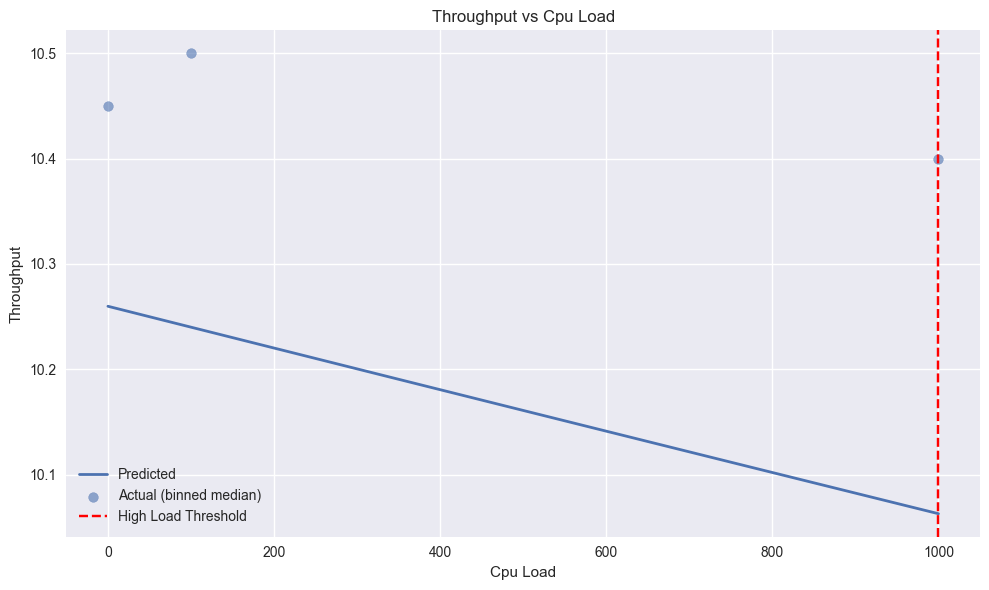

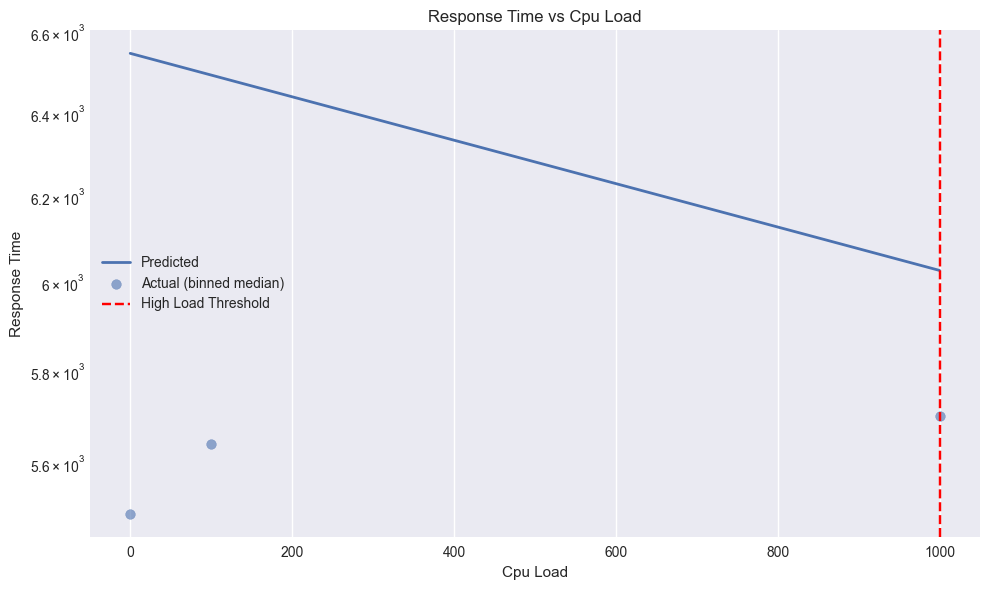

In [34]:
"""
cpu load Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_cpu_load_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    cpu_load_range = np.linspace(
        df['cpuLoad'].min(),
        df['cpuLoad'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['cpuLoad'] = cpu_load_range

    return cpu_load_range, X_sweep.values


def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin cpu load to smooth curve
    df['cpuLoad_bin'] = pd.cut(df['cpuLoad'], bins=bins)

    grouped = (
        df.groupby('cpuLoad_bin')[['cpuLoad', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['cpuLoad'], grouped


cpu_load_range, X_sweep = create_cpu_load_sweep(train, X_cols)
cpu_load_actual, df_actual = get_actual_curve(train)



# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Throughput")
plt.title("Throughput vs Cpu Load")

# Optional: mark high-load region
plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_throughput_vs_cpu_load.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Response Time")
plt.title("Response Time vs Cpu Load")

plt.yscale('log')

plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_response_time_vs_cpu_load.png', dpi=300)

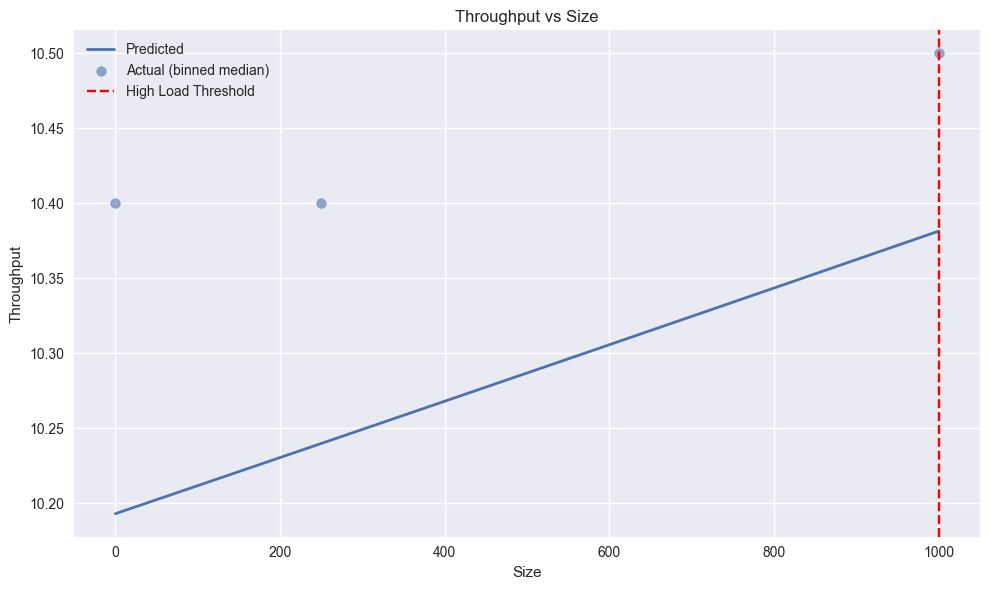

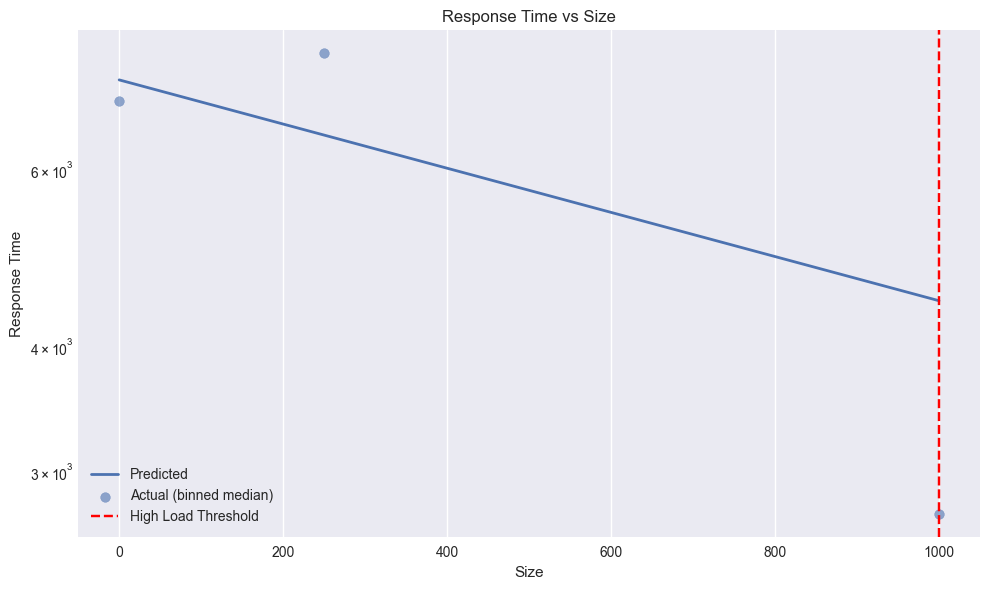

In [35]:
"""
Size Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_size_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    size_range = np.linspace(
        df['size'].min(),
        df['size'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['size'] = size_range

    return size_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin size to smooth curve
    df['Size_bin'] = pd.cut(df['size'], bins=bins)

    grouped = (
        df.groupby('Size_bin')[['size', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['size'], grouped


size_range, X_sweep = create_size_sweep(train, X_cols)
size_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Throughput")
plt.title("Throughput vs Size")

# Optional: mark high-load region
plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_throughput_vs_size.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Response Time")
plt.title("Response Time vs Size")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('regression_response_time_vs_size.png', dpi=300)

In [36]:
"""
Queueing-Aware Linear Regression Pipeline
(With engineered nonlinear + interaction features)
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import loguniform


df_train = pd.read_csv('ram.csv')
df_test = pd.read_csv('testram.csv')


def convert_memory(mem_str):
    mem_str = str(mem_str).lower()
    if 'g' in mem_str:
        return float(mem_str.replace('g', '')) * 1024
    elif 'm' in mem_str:
        return float(mem_str.replace('m', ''))
    return float(mem_str)

def preprocess(df):
    df = df.copy()

    df['device_write_numeric'] = df['device_write'].str.replace('mb', '').astype(float)
    df['memory_numeric'] = df['memory'].apply(convert_memory)

    df = df[df['Throughput'] != 0]

    # -------- Queueing Features --------
    df['service_rate'] = df['cpus'] * (1 - df['cpuLoad']) + 1e-6
    df['rho'] = df['ArrivalRate'] / df['service_rate']
    df['rho_sq'] = df['rho'] ** 2
    df['inv_1_minus_rho'] = 1 / (1 - df['rho'] + 1e-6)

    # -------- Interaction Features --------
    df['arrival_x_cpu'] = df['ArrivalRate'] * df['cpus']
    df['arrival_x_load'] = df['ArrivalRate'] * df['cpuLoad']
    df['cpu_x_mem'] = df['cpus'] * df['memory_numeric']
    df['size_x_write'] = df['size'] * df['device_write_numeric']

    # -------- Quadratic Features --------
    df['ArrivalRate_sq'] = df['ArrivalRate'] ** 2
    df['cpuLoad_sq'] = df['cpuLoad'] ** 2
    df['size_sq'] = df['size'] ** 2

    # -------- Log Features --------
    df['log_arrival'] = np.log1p(df['ArrivalRate'])
    df['log_size'] = np.log1p(df['size'])
    df['log_memory'] = np.log1p(df['memory_numeric'])

    return df

train = preprocess(df_train)
test = preprocess(df_test)


X_cols = [
    'ArrivalRate', 'cpus', 'size', 'cpuLoad',
    'device_write_numeric', 'memory_numeric',

    # queueing
    'service_rate', 'rho', 'rho_sq', 'inv_1_minus_rho',

    # interactions
    'arrival_x_cpu', 'arrival_x_load',
    'cpu_x_mem', 'size_x_write',

    # quadratic
    'ArrivalRate_sq', 'cpuLoad_sq', 'size_sq',

    # logs
    'log_arrival', 'log_size', 'log_memory'
]

X_train = train[X_cols].values
X_test = test[X_cols].values

# Log-transform targets
y_tp_train = np.log1p(train['Throughput'].values)
y_tp_test = np.log1p(test['Throughput'].values)

y_rt_train = np.log1p(train['ResponseTime'].values)
y_rt_test = np.log1p(test['ResponseTime'].values)


def p90_ape(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100
    return np.percentile(pct_err, 90)

from sklearn.metrics import make_scorer
p90_scorer = make_scorer(p90_ape, greater_is_better=False)


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=20000))
])

param_dist = {
    'model__alpha': loguniform(1e-4, 10),
    'model__l1_ratio': np.linspace(0.1, 0.9, 9)
}

def tune(X, y, name):
    print(f"\nTuning {name} (P90 APE)...")

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=25,
        scoring=p90_scorer,
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best CV P90 APE:", -search.best_score_)

    return search.best_estimator_


model_tp = tune(X_train, y_tp_train, "Throughput")
model_rt = tune(X_train, y_rt_train, "Response Time")


def evaluate(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100

    p90 = np.percentile(pct_err, 90)
    mape = np.mean(pct_err)
    smape = np.mean(2 * np.abs(y_pred - y_true) /
                    (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)

    acc_10 = (pct_err <= 10).mean() * 100
    acc_20 = (pct_err <= 20).mean() * 100
    acc_50 = (pct_err <= 50).mean() * 100
    acc_90 = (pct_err <= 90).mean() * 100

    print(f"\n{name} RESULTS")
    print("-" * 40)
    print(f"P90 APE:        {p90:.2f}%  PRIMARY METRIC")
    print(f"MAPE:           {mape:.2f}%")
    print(f"SMAPE:          {smape:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"R²:             {r2:.4f}")
    print(f"Acc ≤10%:       {acc_10:.2f}%")
    print(f"Acc ≤20%:       {acc_20:.2f}%")
    print(f"Acc ≤50%:       {acc_50:.2f}%")
    print(f"Acc ≤90%:       {acc_90:.2f}%")


evaluate(y_tp_test, model_tp.predict(X_test), "THROUGHPUT")
evaluate(y_rt_test, model_rt.predict(X_test), "RESPONSE TIME")


Tuning Throughput (P90 APE)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'model__alpha': np.float64(0.0074593432857265485), 'model__l1_ratio': np.float64(0.8)}
Best CV P90 APE: 124.64987107640131

Tuning Response Time (P90 APE)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'model__alpha': np.float64(0.00010847546640130752), 'model__l1_ratio': np.float64(0.9)}
Best CV P90 APE: 1830.6197482613873

THROUGHPUT RESULTS
----------------------------------------
P90 APE:        37.70%  PRIMARY METRIC
MAPE:           14.89%
SMAPE:          0.1480
RMSE:           2.6231
MAE:            1.8987
R²:             0.3806
Acc ≤10%:       33.33%
Acc ≤20%:       80.00%
Acc ≤50%:       100.00%
Acc ≤90%:       100.00%

RESPONSE TIME RESULTS
----------------------------------------
P90 APE:        1122.53%  PRIMARY METRIC
MAPE:           369.64%
SMAPE:          1.0588
RMSE:           26336.8320
MAE:            20035.5790
R²:             0.086

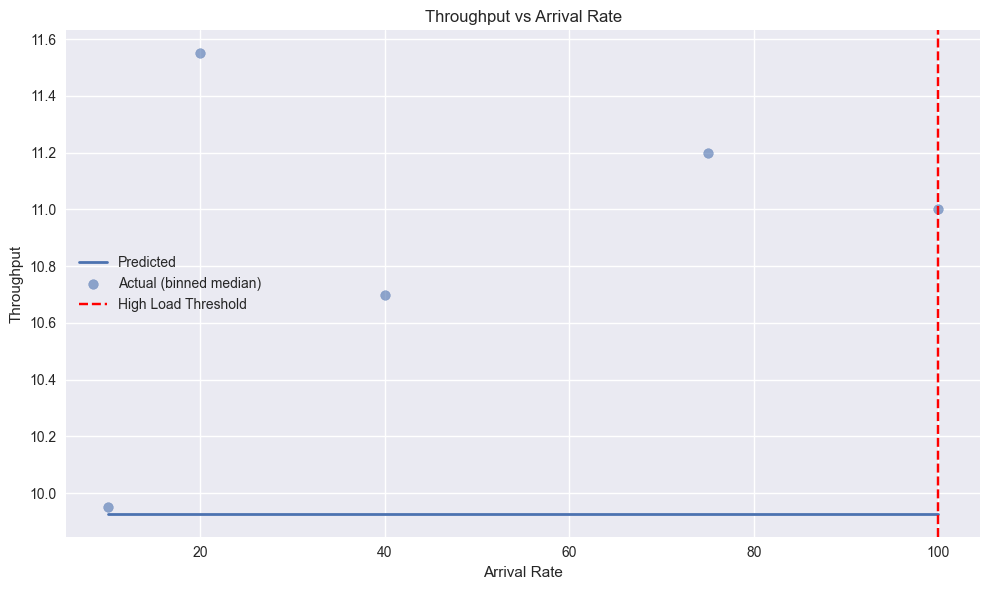

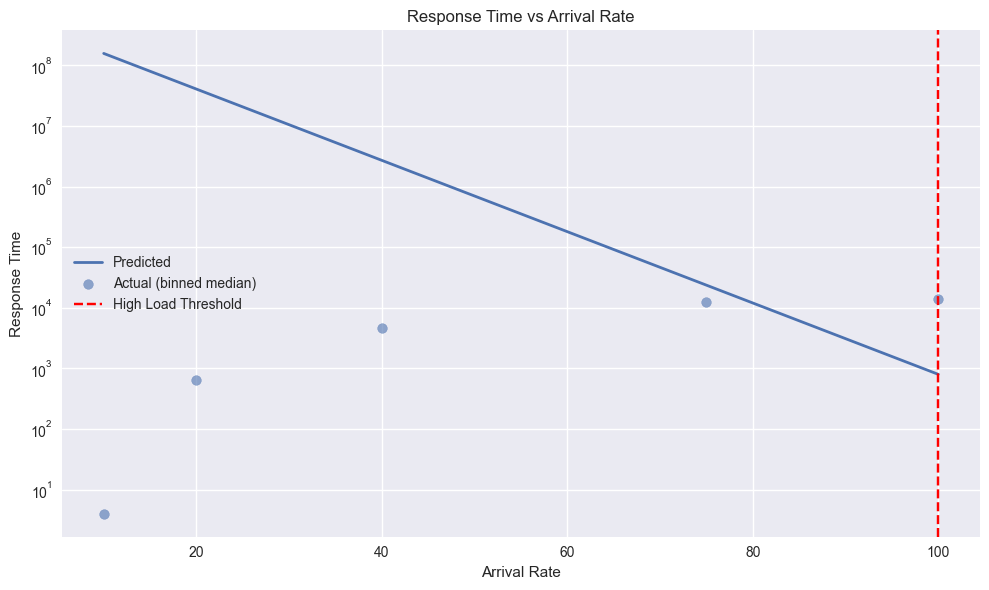

In [37]:
"""
Arrival Rate Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_arrival_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    arrival_range = np.linspace(
        df['ArrivalRate'].min(),
        df['ArrivalRate'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['ArrivalRate'] = arrival_range

    return arrival_range, X_sweep.values


def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin arrival rate to smooth curve
    df['Arrival_bin'] = pd.cut(df['ArrivalRate'], bins=bins)

    grouped = (
        df.groupby('Arrival_bin')[['ArrivalRate', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['ArrivalRate'], grouped



arrival_range, X_sweep = create_arrival_sweep(train, X_cols)
arrival_actual, df_actual = get_actual_curve(train)



# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))

plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Throughput")
plt.title("Throughput vs Arrival Rate")

# Optional: mark high-load region
plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('better_regression_throughput_vs_arrival_rate.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Response Time")
plt.title("Response Time vs Arrival Rate")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('better_regression_response_time_vs_arrival_rate.png', dpi=300)

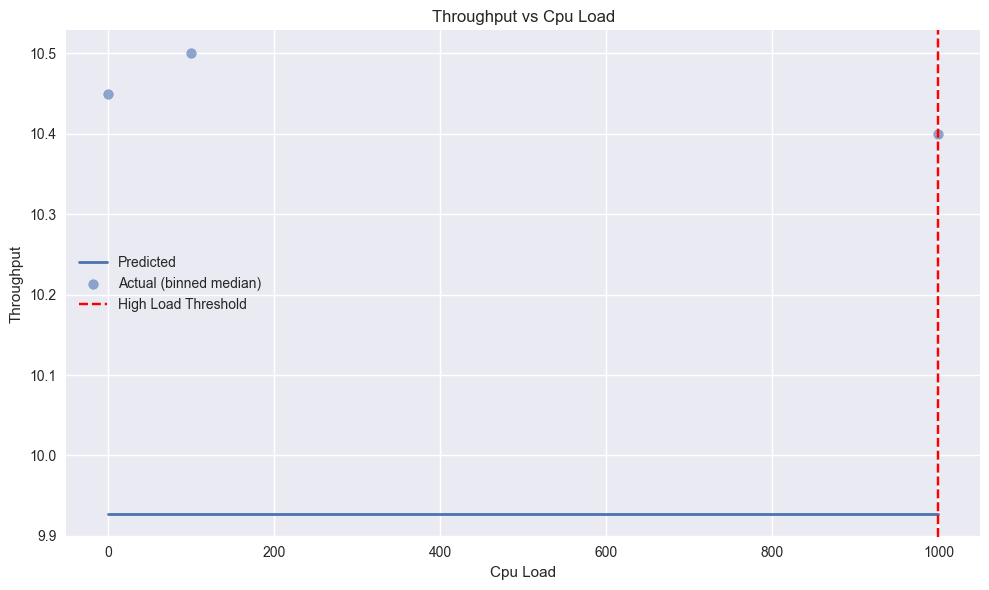

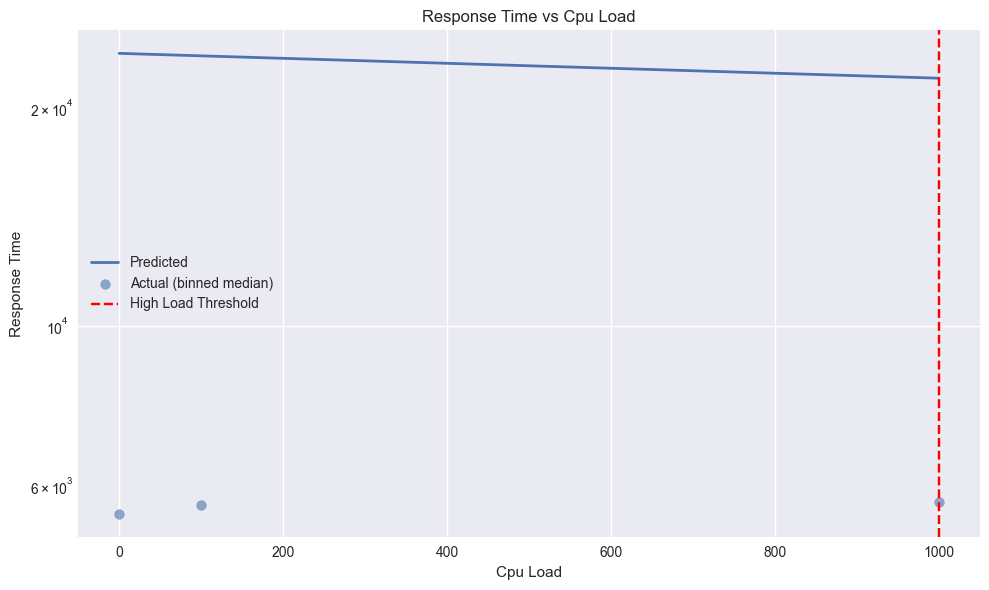

In [38]:
"""
cpu load Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


def create_cpu_load_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    cpu_load_range = np.linspace(
        df['cpuLoad'].min(),
        df['cpuLoad'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['cpuLoad'] = cpu_load_range

    return cpu_load_range, X_sweep.values


def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin cpu load to smooth curve
    df['cpuLoad_bin'] = pd.cut(df['cpuLoad'], bins=bins)

    grouped = (
        df.groupby('cpuLoad_bin')[['cpuLoad', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['cpuLoad'], grouped



cpu_load_range, X_sweep = create_cpu_load_sweep(train, X_cols)
cpu_load_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))



plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Throughput")
plt.title("Throughput vs Cpu Load")

# Optional: mark high-load region
plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('better_regression_throughput_vs_cpu_load.png', dpi=300)


# ============================================
# PLOT: RESPONSE TIME
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Response Time")
plt.title("Response Time vs Cpu Load")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('better_regression_response_time_vs_cpu_load.png', dpi=300)

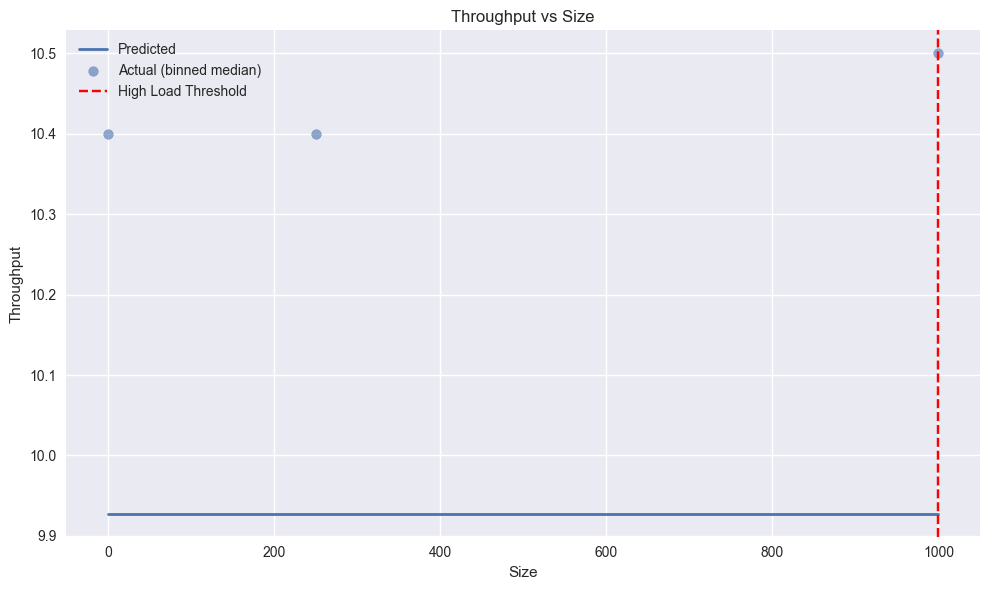

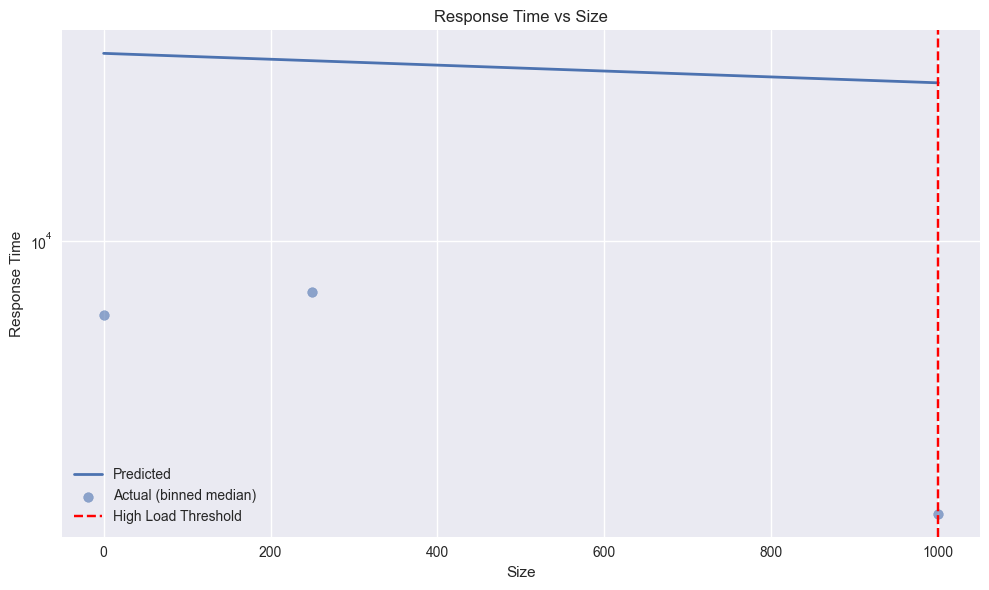

In [39]:
"""
Size Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_size_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    size_range = np.linspace(
        df['size'].min(),
        df['size'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['size'] = size_range

    return size_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin size to smooth curve
    df['Size_bin'] = pd.cut(df['size'], bins=bins)

    grouped = (
        df.groupby('Size_bin')[['size', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['size'], grouped


size_range, X_sweep = create_size_sweep(train, X_cols)
size_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Throughput")
plt.title("Throughput vs Size")

# Optional: mark high-load region
plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('better_regression_throughput_vs_size.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Response Time")
plt.title("Response Time vs Size")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('better_regression_response_time_vs_size.png', dpi=300)